In [3]:
import pandas as pd
data=pd.read_csv("Titanic-Dataset.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [23]:
data['Age']=data['Age'].fillna(data['Age'].mean())
data['Sex']=data['Sex'].map({'male':0,'female':1})

In [24]:
X=data[['Pclass','Sex','Age']]
y=data['Survived']

In [25]:
X=X.astype(float)
y=y.astype(int)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_size=42)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=200)
model.fit(X_train,y_train)

In [12]:
print("Accuracy:",model.score(X_test,y_test))

Accuracy: 0.8048780487804879


In [14]:
y_pred=model.predict(X_test)
print("Predictions:",y_pred[:10])
      

Accuracy: 0.8048780487804879
Predictions: [1 1 1 1 1 1 0 1 1 1]


In [15]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[ 7  4]
 [ 4 26]]
              precision    recall  f1-score   support

           0       0.64      0.64      0.64        11
           1       0.87      0.87      0.87        30

    accuracy                           0.80        41
   macro avg       0.75      0.75      0.75        41
weighted avg       0.80      0.80      0.80        41



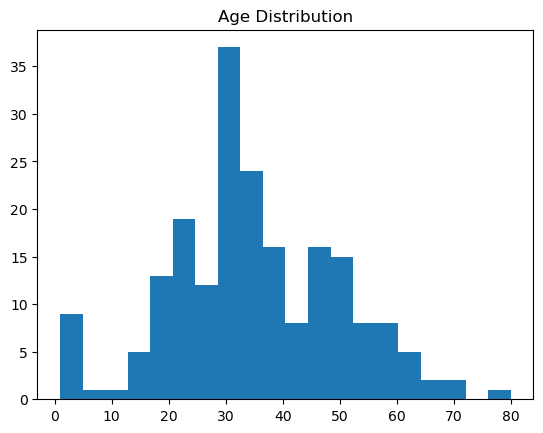

In [16]:
import matplotlib.pyplot as plt
plt.hist(data['Age'],bins=20)
plt.title('Age Distribution')
plt.show()

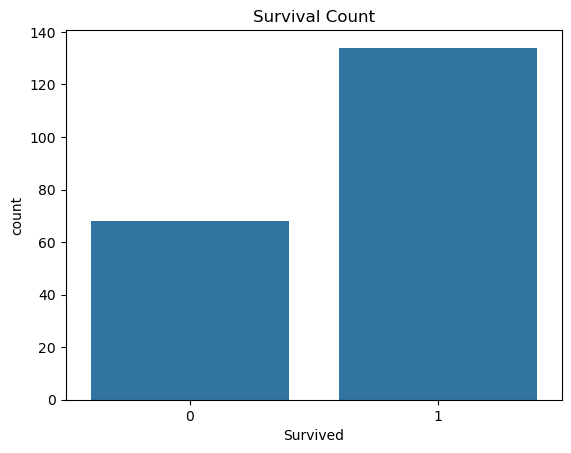

In [17]:
import seaborn as sns
sns.countplot(x='Survived',data=data)
plt.title('Survival Count')
plt.show()

In [20]:
from sklearn.tree import DecisionTreeClassifier
model2=DecisionTreeClassifier()
model2.fit(X_train,y_train)
print("Decision Tree Accuracy:",model2.score(X_test,y_test))

Decision Tree Accuracy: 0.7804878048780488


In [21]:
print("Logistic Regression:",model.score(X_test,y_test))
print("Decision Tree:",model2.score(X_test,y_test))

Logistic Regression: 0.8048780487804879
Decision Tree: 0.7804878048780488


In [28]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [29]:
from sklearn.ensemble import RandomForestClassifier
model3=RandomForestClassifier()
model3.fit(X_train,y_train)
print("Random Forest:",model3.score(X_test,y_test))

Random Forest: 0.8536585365853658
